# Proyecto de Grafos - Estilo de Juego: Francia

## Objetivo
Construir un grafo que represente como circulo el balon entre los jugadores de
Francia durante la fase de grupos del Mundial Qatar 2022, e interpretar el
estilo de juego del equipo a partir de la estructura de ese grafo.

In [1]:
import pandas as pd

# 1) Cargamos el csv de Francia
df = pd.read_csv("pases_francia.csv")

# 2) Nos quedamos solo con fase de grupos, y luego separamos por partido
df_grupos = df[df["fase"] == "Group Stage"]

df_tunisia = df_grupos[df_grupos["oponente"] == "Tunisia"]
df_denmark = df_grupos[df_grupos["oponente"] == "Denmark"]
df_australia = df_grupos[df_grupos["oponente"] == "Australia"]

print("Filas totales:", len(df))
print("Filas solo fase de grupos:", len(df_grupos))
print("Filas para partido uno, dos y tres:", len(df_tunisia), len(df_denmark), len(df_australia))

Filas totales: 3926
Filas solo fase de grupos: 1964
Filas para partido uno, dos y tres: 661 540 763


## Importación de la librería networkx

In [2]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.


## Construcción del grafo dirigido

In [3]:
import networkx as nx

# 1) Filtramos solo los pases completados
df_completos = df_tunisia[df_tunisia["resultado"] == "Complete"]
df_completos1 = df_denmark[df_denmark["resultado"] == "Complete"]
df_completos2 = df_australia[df_australia["resultado"] == "Complete"]

# 2) Creamos el grafo dirigido
G1 = nx.DiGraph()
G2 = nx.DiGraph()
G3 = nx.DiGraph()


# 3) Recorremos cada pase y agregamos la conexión
for _, fila in df_completos.iterrows():
    emisor = fila["jugador_nombre"]
    receptor = fila["receptor_nombre"]
    #print(f"Voy a conectar a: {emisor} con {receptor}") para debug
    G1.add_edge(emisor, receptor)
    


for _, fila in  df_completos1.iterrows():
    emisor = fila["jugador_nombre"]
    receptor = fila["receptor_nombre"]
    G2.add_edge(emisor,receptor)


for _, fila in df_completos2.iterrows():
    emisor = fila["jugador_nombre"]
    receptor = fila["receptor_nombre"]
    G3.add_edge(emisor,receptor)

# 4) Vistazo rápido para confirmar que el grafo se armó bien
print('\n')
print("Numero de pases (aristas):", G1.number_of_edges())
print("Numero de jugadores (nodos):", G1.number_of_nodes())
print('\n')
print("Ejemplo de conexiones:")
for emisor, receptor in list(G1.edges())[:5]:
    print(f"  {emisor} -> {receptor}")
    
print('\n')
print("Numero de jugadores (nodos):", G2.number_of_nodes())
print("Numero de pases (aristas):", G2.number_of_edges())
print('\n')
print("Ejemplo de conexiones:")
for emisor, receptor in list(G2.edges())[:5]:
    print(f"  {emisor} -> {receptor}")

print('\n')
print("Numero de pases (aristas):", G3.number_of_edges())
print("Numero de jugadores (nodos):", G3.number_of_nodes())
print('\n')
for emisor, receptor in list(G3.edges())[:5]:
    print(f"  {emisor} -> {receptor}")

print("Ejemplo de conexiones:")



Numero de pases (aristas): 150
Numero de jugadores (nodos): 16


Ejemplo de conexiones:
  Steve Mandanda -> Raphaël Varane
  Steve Mandanda -> Eduardo Camavinga
  Steve Mandanda -> Ibrahima Konaté
  Steve Mandanda -> Jordan Veretout
  Steve Mandanda -> Aurélien Djani Tchouaméni


Numero de jugadores (nodos): 15
Numero de pases (aristas): 118


Ejemplo de conexiones:
  Ousmane Dembélé -> Jules Koundé
  Ousmane Dembélé -> Adrien Rabiot
  Ousmane Dembélé -> Antoine Griezmann
  Ousmane Dembélé -> Olivier Giroud
  Ousmane Dembélé -> Aurélien Djani Tchouaméni


Numero de pases (aristas): 127
Numero de jugadores (nodos): 15


  Olivier Giroud -> Aurélien Djani Tchouaméni
  Olivier Giroud -> Antoine Griezmann
  Olivier Giroud -> Theo Bernard François Hernández
  Olivier Giroud -> Kylian Mbappé Lottin
  Aurélien Djani Tchouaméni -> Adrien Rabiot
Ejemplo de conexiones:


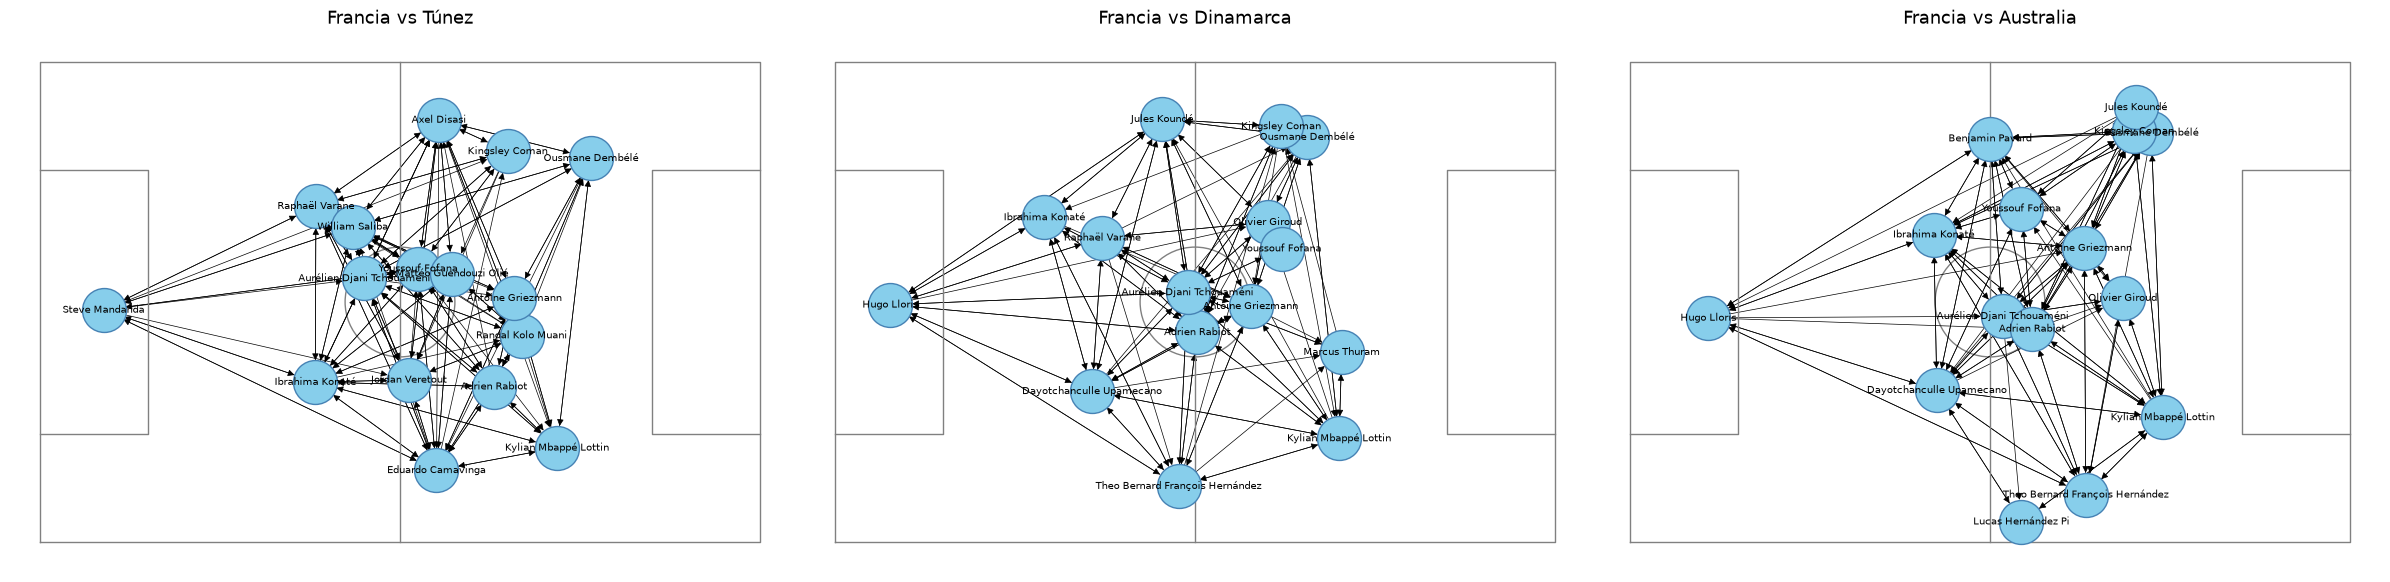

In [4]:
from matplotlib import pyplot as plt
import networkx as nx

def obtener_posiciones(df_partido):
    # Calcula la posicion promedio de cada jugador en la cancha durante un partido
    salidas = df_partido[["jugador_nombre", "inicio_x", "inicio_y"]].rename(
        columns={"jugador_nombre": "jugador", "inicio_x": "x", "inicio_y": "y"}
    )
    llegadas = df_partido[["receptor_nombre", "fin_x", "fin_y"]].rename(
        columns={"receptor_nombre": "jugador", "fin_x": "x", "fin_y": "y"}
    )
    todas_posiciones = pd.concat([salidas, llegadas])
    promedio = todas_posiciones.groupby("jugador")[["x", "y"]].mean()
    return {jugador: (fila["x"], fila["y"]) for jugador, fila in promedio.iterrows()}


def dibujar_cancha(ax):
    # Dibuja lineas basicas de una cancha de futbol, de fondo
    ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="gray", linewidth=1)
    ax.plot([60, 60], [0, 80], color="gray", linewidth=1)
    circulo = plt.Circle((60, 40), 9.15, color="gray", fill=False, linewidth=1)
    ax.add_patch(circulo)
    ax.plot([0, 18, 18, 0], [18, 18, 62, 62], color="gray", linewidth=1)
    ax.plot([120, 102, 102, 120], [18, 18, 62, 62], color="gray", linewidth=1)


fig, axes = plt.subplots(1, 3, figsize=(24, 10))
grafos = [
    (G1, df_tunisia, "Francia vs Túnez"),
    (G2, df_denmark, "Francia vs Dinamarca"),
    (G3, df_australia, "Francia vs Australia")
]
for ax, (G, df_partido, titulo) in zip(axes, grafos):
    pos = obtener_posiciones(df_partido)

    dibujar_cancha(ax)

    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        node_size=1000,
        font_size=7,
        width=0.5,
        arrows=True,
        node_color="skyblue",
        edgecolors="steelblue"
    )

    ax.set_title(titulo, fontsize=13)
    ax.set_xlim(-5, 125)
    ax.set_ylim(-5, 85)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()